# QuantumEdge - GIC 2026 Phase 3 (final)
## Dual-Timescale Quantum Reservoir Computing for S&P 500 Realized-Variance Forecasting
**Track A: Financial Volatility Prediction**

Reproducible reference implementation reflecting our validated results. Headline model is **Dual-timescale + Pauli
readout + feedback (Dual+Pauli+FB)** - our best configuration and fully hardware-native (Pauli observables only).
A **calibrated** variant adds a leakage-free bias correction that improves QLIKE. Sections 12-16 are the Phase 3
execution studies (run on the full split); Section 17 is the IBM hardware lane; Section 18 builds the figures.

**Run:** `Kernel -> Restart & Run All`. Build the data once with `fetch_data.ipynb` (or `fetch_data.py`) and commit
`data/market_data.csv`. Studies run on the full dataset by default (~10-15 min on CPU; faster on GPU).

**Platform:** IBM Quantum via qBraid (confirmed acceptable for Phase 3 by the organizers); QPU validation on `ibm_fez`.
**Launch on qBraid:** https://github.com/qBraid/community/discussions/3


### 0. Setup - install dependencies into THIS kernel
Run first. Installs only what's missing; safe to re-run. Fixes ModuleNotFoundError on minimal kernels.

In [1]:
import importlib.util, subprocess, sys
_need={"pandas":"pandas","numpy":"numpy","qiskit":"qiskit","qiskit_aer":"qiskit-aer",
       "sklearn":"scikit-learn","statsmodels":"statsmodels","matplotlib":"matplotlib",
       "yfinance":"yfinance","qiskit_ibm_runtime":"qiskit-ibm-runtime",
       "arch":"arch"}
_m=[p for k,p in _need.items() if importlib.util.find_spec(k) is None]
if _m:
    print("installing:",_m); subprocess.run([sys.executable,"-m","pip","install","--quiet","--break-system-packages",*_m],check=True)
    print("done - if imports below fail, restart the kernel and run again.")
else: print("all dependencies present")

all dependencies present


### 1. Imports, versions, seed

In [1]:
import os, time, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm
SEED=7; np.random.seed(SEED)
print("qiskit",qiskit.__version__,"| numpy",np.__version__,"| seed",SEED)

qiskit 2.4.2 | numpy 2.5.1 | seed 7


### 2. Configuration

In [2]:
CONFIG=dict(
    data_csv="data/market_data.csv", allow_download=True, use_synthetic=False,
    window=22, train_frac=0.80, enc_low=-np.pi/2, enc_high=np.pi/2,
    features_cache="data/qrc_pauli_features.npy",
    n_qubits=9, short=dict(J=0.3,h=1.0,p=2), long=dict(J=1.2,h=0.4,p=6),
    ent_keep=8, dt=1.0, feedback=True, gamma=0.5, mem_dim=3,
    headline_pauli_only=True,      # best config is Pauli-only (hardware-native)
    bias_correction=True,          # leakage-free calibrated variant (improves QLIKE)
    ridge_alphas=np.logspace(-4,3,25),
    study_sample=None,             # None = full dataset for studies
    scan_n=[5,7,9,11], scan_p=[2,4], enc_fracs=[0.34,0.67,1.0], shot_list=[256,1024,4096],
    noise_levels=[0.005,0.01,0.02], zne_scales=[1,3,5], noise_n=5, noise_windows=8,
    USE_HARDWARE=False, ibm_backend="ibm_fez",  # IBM confirmed platform; ibm_fez declared (ibm_kingston=alt); auto-fallback to least-busy
    hw_n_qubits=7, hw_p=2, hw_windows=3, shots=4096, run_garch=True, run_lstm=True,
)
os.makedirs("data",exist_ok=True); CONFIG

{'data_csv': 'data/market_data.csv',
 'allow_download': True,
 'use_synthetic': False,
 'window': 22,
 'train_frac': 0.8,
 'enc_low': -1.5707963267948966,
 'enc_high': 1.5707963267948966,
 'features_cache': 'data/qrc_pauli_features.npy',
 'n_qubits': 9,
 'short': {'J': 0.3, 'h': 1.0, 'p': 2},
 'long': {'J': 1.2, 'h': 0.4, 'p': 6},
 'ent_keep': 8,
 'dt': 1.0,
 'feedback': True,
 'gamma': 0.5,
 'mem_dim': 3,
 'headline_pauli_only': True,
 'bias_correction': True,
 'ridge_alphas': array([1.00000000e-04, 1.95734178e-04, 3.83118685e-04, 7.49894209e-04,
        1.46779927e-03, 2.87298483e-03, 5.62341325e-03, 1.10069417e-02,
        2.15443469e-02, 4.21696503e-02, 8.25404185e-02, 1.61559810e-01,
        3.16227766e-01, 6.18965819e-01, 1.21152766e+00, 2.37137371e+00,
        4.64158883e+00, 9.08517576e+00, 1.77827941e+01, 3.48070059e+01,
        6.81292069e+01, 1.33352143e+02, 2.61015722e+02, 5.10896977e+02,
        1.00000000e+03]),
 'study_sample': None,
 'scan_n': [5, 7, 9, 11],
 'scan_p': 

### 3. Data - Garman-Klass realized variance (cached, judge-reproducible)
Targets a daily range-based realized-variance proxy from public OHLC. Reads a committed CSV so judges reproduce the
exact input; synthetic is opt-in only and loudly flagged (never a silent substitute).

In [3]:
def garman_klass(px):
    o,h,l,c=np.log(px["Open"]),np.log(px["High"]),np.log(px["Low"]),np.log(px["Close"])
    return (0.5*(h-l)**2-(2*np.log(2)-1)*(c-o)**2).clip(lower=1e-10)
def make_synthetic(T=3800,seed=SEED):
    r=np.random.default_rng(seed); reg=np.zeros(T,int); s=0
    for t in range(1,T):
        s=1-s if r.random()<(0.02 if s==0 else 0.05) else s; reg[t]=s
    mu=np.where(reg==0,np.log(7e-5),np.log(3e-4)); x=np.empty(T); x[0]=mu[0]
    for t in range(1,T): x[t]=0.94*x[t-1]+0.06*mu[t]+0.12*r.standard_normal()
    rv=np.exp(x); ret=np.sqrt(rv)*r.standard_normal(T); vix=100*np.sqrt(252*rv)+3*r.standard_normal(T)
    return pd.DataFrame({"ret":ret,"rv":rv,"vix":vix},index=pd.bdate_range("2010-01-01",periods=T))
def download_and_cache(cfg):
    import yfinance as yf
    def flat(d):
        if isinstance(d.columns,pd.MultiIndex): d.columns=d.columns.get_level_values(0)
        return d
    px=flat(yf.download("^GSPC",start="2010-01-01",end="2025-01-01",auto_adjust=False,progress=False))
    vx=flat(yf.download("^VIX",start="2010-01-01",end="2025-01-01",auto_adjust=False,progress=False))
    df=pd.DataFrame(index=px.index); df["ret"]=np.log(px["Close"]).diff(); df["rv"]=garman_klass(px)
    df["vix"]=vx["Close"].reindex(px.index).ffill(); df=df.dropna(); df.to_csv(cfg["data_csv"]); return df
def load_data(cfg):
    if cfg["use_synthetic"]:
        print("!!! use_synthetic=True -> DEMO ONLY, NOT submission numbers."); return make_synthetic(),"SYNTHETIC (demo only)"
    if os.path.exists(cfg["data_csv"]):
        return pd.read_csv(cfg["data_csv"],index_col=0,parse_dates=True), f"cached CSV ({cfg['data_csv']})"
    if cfg["allow_download"]:
        try: return download_and_cache(cfg),"yfinance (downloaded + cached)"
        except Exception as e: raise RuntimeError(f"download failed ({e}). Run fetch_data.ipynb on qBraid and commit the CSV.")
    raise FileNotFoundError("No data/market_data.csv. Run fetch_data.ipynb once and commit it.")
data,data_src=load_data(CONFIG)
print(f"source: {data_src} | rows: {len(data)} | {data.index[0].date()} -> {data.index[-1].date()}"); data.head()

source: cached CSV (data/market_data.csv) | rows: 3773 | 2010-01-05 -> 2024-12-31


,ret,rv,vix,nfci
Date,,,,
2010-01-05,0.003111,0.000014,19.35,NaN
2010-01-06,0.000545,0.000010,19.16,NaN
2010-01-07,0.003993,0.000039,19.06,NaN
2010-01-08,0.002878,0.000026,18.13,-0.191
2010-01-11,0.001745,0.000022,17.55,-0.191


### 4. Preprocessing - HAR-informed features, scaling, splits, regimes

In [4]:
def build_features(data,cfg):
    lrv=np.log(data["rv"].values); vsp=data["vix"].values/100.0-np.sqrt(252*data["rv"].values)
    L=cfg["window"]; F,y,idx=[],[],[]
    for t in range(L,len(lrv)-1):
        w=lrv[t-L+1:t+1]; F.append([lrv[t],w[-5:].mean(),w.mean(),lrv[t]-lrv[t-1],vsp[t]]); y.append(lrv[t+1]); idx.append(t)
    return np.array(F),np.array(y),np.array(idx)
F,y,idx=build_features(data,CONFIG); ntr=int(CONFIG["train_frac"]*len(y))
enc=MinMaxScaler((CONFIG["enc_low"],CONFIG["enc_high"])).fit(F[:ntr]); Fs=enc.transform(F)
q1,q2=np.quantile(np.exp(y)[:ntr],[1/3,2/3])
def to_regime(v): return np.where(v<q1,0,np.where(v<q2,1,2))
yt=y[ntr:]; test_idx=np.arange(ntr,len(y))
print(f"samples {len(y)} | train {ntr} | test {len(yt)} | features/day {F.shape[1]}")

samples 3750 | train 3000 | test 750 | features/day 5


### 5. Reservoir design - two transverse-field Ising chains
Short ($J{=}0.3,h{=}1.0,p{=}2$, paramagnetic) for fast decorrelation; long ($J{=}1.2,h{=}0.4,p{=}6$, ferromagnetic)
for memory. `enc_frac` sets encoding density.

In [5]:
def reservoir_circuit(x,n,J,h,p,dt=1.0,enc_frac=1.0):
    qc=QuantumCircuit(n); ne=max(1,int(round(enc_frac*n)))
    for _ in range(p):
        for q in range(ne): qc.ry(float(x[q%len(x)]),q)
        for i in range(n-1): qc.rzz(2*J*dt,i,i+1)
        for i in range(n): qc.rx(2*h*dt,i)
    return qc
ds=reservoir_circuit(Fs[0],CONFIG["n_qubits"],**CONFIG["short"],dt=CONFIG["dt"])
dl=reservoir_circuit(Fs[0],CONFIG["n_qubits"],**CONFIG["long"],dt=CONFIG["dt"])
print(f"short: {ds.num_qubits}q depth {ds.depth()} | long: {dl.num_qubits}q depth {dl.depth()}")

short: 9q depth 14 | long: 9q depth 30


### 6. Recurrent readout (Pauli observables + fading memory)
Headline readout uses **Pauli** observables only ($\langle Z_i\rangle,\langle Z_iZ_{i+1}\rangle$) - all hardware-measurable.
Feedback is a leaky integrator of measured observables fed into the next encoding: genuine fading memory. The
entanglement-spectrum features are available for the ablation (Section 12) but are simulator-only and are not in the
headline model, because the ablation shows they do not improve forecasting.

In [6]:
def z_ops(n):
    ops=[]
    for i in range(n):
        l=["I"]*n; l[i]="Z"; ops.append(SparsePauliOp("".join(l[::-1])))
    for i in range(n-1):
        l=["I"]*n; l[i]="Z"; l[i+1]="Z"; ops.append(SparsePauliOp("".join(l[::-1])))
    return ops
def pauli_features(sv,n): return [np.real(sv.expectation_value(o)) for o in z_ops(n)]
def ent_features(sv,n,keep):
    rho=partial_trace(sv,list(range(n//2,n))); e=np.clip(np.real(np.linalg.eigvalsh(rho.data)),1e-12,None)
    e=np.sort(e)[::-1][:keep]; xi=-np.log(e)
    if len(xi)<keep: xi=np.pad(xi,(0,keep-len(xi)),constant_values=xi[-1])
    return list(xi)
def reservoir_features(Fs,n,res,cfg,feedback=None,pauli_only=True,enc_frac=1.0):
    fb=cfg["feedback"] if feedback is None else feedback
    mem=np.zeros(cfg["mem_dim"]); out=[]
    for row in Fs:
        x=np.concatenate([row,mem]) if fb else row
        sv=Statevector(reservoir_circuit(x,n,res["J"],res["h"],res["p"],cfg["dt"],enc_frac))
        pf=pauli_features(sv,n)
        out.append(pf if pauli_only else pf+ent_features(sv,n,cfg["ent_keep"]))
        if fb:
            s=np.array([np.mean(pf[:n]),np.mean(pf[n:]),np.std(pf[:n])])[:cfg["mem_dim"]]
            mem=(1-cfg["gamma"])*mem+cfg["gamma"]*s
    return np.array(out)

### 7. Build the headline feature matrix (Dual + Pauli + FB)

In [7]:
cache=CONFIG["features_cache"]
if os.path.exists(cache):
    Q=np.load(cache); print(f"loaded cache {Q.shape}")
else:
    t0=time.time()
    Q=np.hstack([reservoir_features(Fs,CONFIG["n_qubits"],CONFIG["short"],CONFIG,pauli_only=CONFIG["headline_pauli_only"]),
                 reservoir_features(Fs,CONFIG["n_qubits"],CONFIG["long"], CONFIG,pauli_only=CONFIG["headline_pauli_only"])])
    np.save(cache,Q); print(f"built {Q.shape} in {time.time()-t0:.1f}s")

loaded cache (3750, 34)


### 8. Metrics and leakage-free bias correction

In [8]:
def rmse(a,b): return float(np.sqrt(np.mean((np.exp(a)-np.exp(b))**2)))
def qlike(a,b):
    v=np.exp(a); f=np.clip(np.exp(b),1e-12,None); return float(np.mean(v/f-np.log(v/f)-1))
def regime_acc(a,b): return float(np.mean(to_regime(np.exp(a))==to_regime(np.exp(b))))
def vol_sharpe(b,ti):
    rn=data["ret"].values[idx[ti]+1]; pos=np.clip(np.median(np.exp(b))/np.exp(b),0,5); s=pos*rn
    return float(np.mean(s)/(np.std(s)+1e-12)*np.sqrt(252))
def mincer_zarnowitz(a,b):
    X=sm.add_constant(np.exp(b)); r=sm.OLS(np.exp(a),X).fit()
    return float(r.params[0]),float(r.params[1]),float(r.f_test((np.eye(2),np.array([0,1]))).pvalue)
def bias_correct(ytr_true,pred_tr,pred_te):
    # affine calibration in variance space; fitted on TRAIN only (no leakage)
    a,b=sm.OLS(np.exp(ytr_true),sm.add_constant(np.exp(pred_tr))).fit().params
    return np.log(np.clip(a+b*np.exp(pred_te),1e-12,None)),(float(a),float(b))

### 9. Train, forecast, and calibrate
Closed-form ridge on standardized Pauli features. The calibrated variant applies the train-fit bias correction.

In [9]:
qrc=make_pipeline(StandardScaler(),RidgeCV(alphas=CONFIG["ridge_alphas"])).fit(Q[:ntr],y[:ntr])
yq=qrc.predict(Q[ntr:]); ytr=qrc.predict(Q[:ntr])
yq_cal,(a_bc,b_bc)=bias_correct(y[:ntr],ytr,yq) if CONFIG["bias_correction"] else (yq,(0,1))
a_mz,b_mz,p_mz=mincer_zarnowitz(yt,yq)
print(f"ridge alpha {qrc[-1].alpha_:.4g}")
print(f"Dual+Pauli+FB           RMSE {rmse(yt,yq):.3e} | QLIKE {qlike(yt,yq):.4f} | Reg {regime_acc(yt,yq)*100:.1f}% | Sharpe {vol_sharpe(yq,test_idx):.3f}")
print(f"Dual+Pauli+FB (calib.)  RMSE {rmse(yt,yq_cal):.3e} | QLIKE {qlike(yt,yq_cal):.4f} | Reg {regime_acc(yt,yq_cal)*100:.1f}% | Sharpe {vol_sharpe(yq_cal,test_idx):.3f}")
print(f"Mincer-Zarnowitz (headline): intercept {a_mz:.2e}, slope {b_mz:.3f}, joint p {p_mz:.3f}")
print("Three key Track A metrics (Patton/Mincer-Zarnowitz): RMSE, QLIKE, and MZ slope->1 (unbiasedness).")
print("Note: results-table RegAcc is the strict 3-tertile metric (~62%); standard 2-state calm/turbulent detection is in Section 9b (~78%).")

ridge alpha 0.3162
Dual+Pauli+FB           RMSE 7.725e-05 | QLIKE 0.3794 | Reg 61.7% | Sharpe 0.441
Dual+Pauli+FB (calib.)  RMSE 7.532e-05 | QLIKE 0.3261 | Reg 57.1% | Sharpe 0.475
Mincer-Zarnowitz (headline): intercept 7.78e-06, slope 1.298, joint p 0.000
Three key Track A metrics (Patton/Mincer-Zarnowitz): RMSE, QLIKE, and MZ slope->1 (unbiasedness).
Note: results-table RegAcc is the strict 3-tertile metric (~62%); standard 2-state calm/turbulent detection is in Section 9b (~78%).


### 9b. Volatility regime detection head (calm vs turbulent) - decision 2
The Track A regime task is detecting calm vs turbulent volatility states. A logistic head on the QRC features
classifies the 2-state regime (turbulent = realized variance above the training median), reported with the
majority-class baseline for honest context. This is the standard calm/turbulent framing; the 3-tertile agreement
in the results table (Section 11) is a stricter secondary metric.

In [10]:
from sklearn.linear_model import LogisticRegression
thr_reg=np.median(np.exp(y)[:ntr]); reg2=(np.exp(y)>thr_reg).astype(int)
_Xr=StandardScaler().fit(Q[:ntr]); _Qr=_Xr.transform(Q)
reg_head=LogisticRegression(max_iter=3000).fit(_Qr[:ntr],reg2[:ntr])
reg2_acc=float(np.mean(reg_head.predict(_Qr[ntr:])==reg2[ntr:]))
maj=float(max(np.mean(reg2[ntr:]),1-np.mean(reg2[ntr:])))
print("Volatility regime detection (calm vs turbulent, 2-state):")
print(f"  QRC-feature classifier accuracy : {reg2_acc*100:.1f}%")
print(f"  majority-class baseline         : {maj*100:.1f}%")
print("  (3-state tertile RegAcc in the results table is a stricter secondary metric.)")

Volatility regime detection (calm vs turbulent, 2-state):
  QRC-feature classifier accuracy : 78.1%
  majority-class baseline         : 64.7%
  (3-state tertile RegAcc in the results table is a stricter secondary metric.)


### 10. Classical baselines

In [13]:
results={}
def logr(name,src,b):
    _,mzs,mzp=mincer_zarnowitz(yt,b)
    results[name]=dict(Src=src,RMSE=rmse(yt,b),QLIKE=qlike(yt,b),MZslope=mzs,MZp=mzp,RegAcc=regime_acc(yt,b),Sharpe=vol_sharpe(b,test_idx))
logr("QRC Dual+Pauli+FB","QRC",yq)
if CONFIG["bias_correction"]: logr("QRC Dual+Pauli+FB (calib.)","QRC",yq_cal)
Xh=np.column_stack([np.ones(len(y)),F[:,0],F[:,1],F[:,2]]); bh=np.linalg.lstsq(Xh[:ntr],y[:ntr],rcond=None)[0]
logr("HAR-RV","Classical",Xh[ntr:]@bh); logr("Persistence","Classical",F[ntr:,0])
def esn(u,ntr,size=200,sr=0.9,seed=SEED):
    r=np.random.default_rng(seed); Win=r.uniform(-0.5,0.5,(size,1)); W=r.uniform(-0.5,0.5,(size,size))
    W*=sr/np.max(np.abs(np.linalg.eigvals(W))); S=np.zeros((len(u),size)); s=np.zeros(size)
    for t in range(len(u)): s=np.tanh(Win[:,0]*u[t]+W@s); S[t]=s
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0).fit(S[:ntr],y[:ntr]).predict(S[ntr:])
logr("ESN","Classical",esn(F[:,0],ntr))
if CONFIG["run_lstm"]:                    # recommended Track A baseline (needs torch; auto-installed on qBraid)
    try:
        import subprocess, sys
        try: import torch, torch.nn as nn
        except Exception:
            subprocess.run([sys.executable,"-m","pip","install","--quiet","--break-system-packages","torch"],check=True); import torch, torch.nn as nn
        torch.manual_seed(SEED); lb=10
        xs=StandardScaler().fit(F[:ntr]); Xs=xs.transform(F)
        ys=StandardScaler().fit(y[:ntr].reshape(-1,1)); Y=ys.transform(y.reshape(-1,1)).ravel()   # standardize target for stable training
        Xseq=np.array([Xs[t-lb:t] for t in range(lb,len(Xs))]); Yseq=Y[lb:]
        tr=np.arange(0,ntr-lb); te=np.arange(ntr-lb,len(Yseq)); vcut=int(0.85*len(tr)); trn,val=tr[:vcut],tr[vcut:]
        T=lambda a: torch.tensor(a,dtype=torch.float32)
        Xt,Yt=T(Xseq[trn]),T(Yseq[trn]).view(-1,1); Xv,Yv=T(Xseq[val]),T(Yseq[val]).view(-1,1); Xe=T(Xseq[te])
        class _LSTM(nn.Module):
            def __init__(s,d,h=64):
                super().__init__(); s.l=nn.LSTM(d,h,batch_first=True); s.dp=nn.Dropout(0.1); s.o=nn.Linear(h,1)
            def forward(s,x): z,_=s.l(x); return s.o(s.dp(z[:,-1,:]))
        m=_LSTM(F.shape[1]); opt=torch.optim.Adam(m.parameters(),lr=3e-3); lf=nn.MSELoss(); n=len(Xt); bs=128
        best=1e9; bad=0; bstate=None
        for e in range(600):                          # early stopping on a held-out validation split
            m.train(); perm=torch.randperm(n)
            for i in range(0,n,bs):
                jb=perm[i:i+bs]; opt.zero_grad(); lf(m(Xt[jb]),Yt[jb]).backward(); opt.step()
            m.eval()
            with torch.no_grad(): v=lf(m(Xv),Yv).item()
            if v<best-1e-5: best=v; bad=0; bstate={k:t.clone() for k,t in m.state_dict().items()}
            else:
                bad+=1
                if bad>=40: break
        m.load_state_dict(bstate); m.eval()
        with torch.no_grad(): pz=m(Xe).numpy().ravel()
        pred=ys.inverse_transform(pz.reshape(-1,1)).ravel()
        logr("LSTM","Classical",pred); print(f"LSTM baseline trained (early-stopped, epoch {e}).")
    except Exception as e:
        print("LSTM skipped (torch unavailable):",e)
if CONFIG["run_garch"]:
    try:
        from arch import arch_model
        r=arch_model(data["ret"].values[idx[:ntr]]*100,vol="GARCH",p=1,q=1).fit(disp="off")
        fc=r.forecast(horizon=len(yt),reindex=False).variance.values[-1]/1e4
        logr("GARCH(1,1)","Classical",np.log(np.clip(fc,1e-12,None)))
    except Exception as e: print("GARCH skipped:",e)
print("baselines:",list(results))

LSTM baseline trained (early-stopped, epoch 43).
baselines: ['QRC Dual+Pauli+FB', 'QRC Dual+Pauli+FB (calib.)', 'HAR-RV', 'Persistence', 'ESN', 'LSTM', 'GARCH(1,1)']


### 11. Headline results table (ranked by RMSE)

In [14]:
def show(d):
    t=pd.DataFrame(d).T[["Src","RMSE","QLIKE","MZslope","MZp","RegAcc","Sharpe"]].sort_values("RMSE")
    f=t.copy(); f["RMSE"]=f["RMSE"].map(lambda x:f"{x:.3e}"); f["QLIKE"]=f["QLIKE"].map(lambda x:f"{x:.4f}")
    f["MZslope"]=f["MZslope"].map(lambda x:f"{x:.3f}"); f["MZp"]=f["MZp"].map(lambda x:f"{x:.3f}")
    f["RegAcc"]=(f["RegAcc"]*100).map(lambda x:f"{x:.1f}%"); f["Sharpe"]=f["Sharpe"].map(lambda x:f"{x:.3f}"); return f
print(f"Data: {data_src} | test days: {len(yt)}"); show(results)

Data: cached CSV (data/market_data.csv) | test days: 750


,Src,RMSE,QLIKE,MZslope,MZp,RegAcc,Sharpe
QRC Dual+Pauli+FB (calib.),QRC,7.532e-05,0.3261,1.465,0.000,57.1%,0.475
QRC Dual+Pauli+FB,QRC,7.725e-05,0.3794,1.298,0.000,61.7%,0.441
ESN,Classical,7.993e-05,0.4588,1.101,0.000,59.1%,0.261
HAR-RV,Classical,8.005e-05,0.4129,1.262,0.000,59.3%,0.302
LSTM,Classical,8.231e-05,0.4297,1.630,0.000,57.6%,0.499
Persistence,Classical,9.530e-05,0.6707,0.453,0.000,57.7%,0.041
"GARCH(1,1)",Classical,1.010e-04,0.6656,-3.098,0.000,45.1%,0.329


### 11b. Authentic realized variance validation (Oxford-Man Realized Library)
Confirms the headline on **genuine 5-minute realized variance** rather than the Garman-Klass proxy. Loads the
committed Oxford-Man `.SPX` series (see `fetch_data.ipynb`), auto-scales it to variance, and forecasts next-day RV
with the same Dual+Pauli+FB QRC vs HAR-RV and Persistence. Gracefully skips if the data is not present.

In [15]:
oxp="data/oxman_spx.csv"
if os.path.exists(oxp):
    rvx=pd.read_csv(oxp)["rv"].dropna().values
    if np.median(rvx)>1e-3:
        rvx=rvx**2; print("[oxman] input was realized volatility; squared to variance.")
    lrv=np.log(np.clip(rvx,1e-12,None)); L=CONFIG["window"]; Fo=[]; yo=[]
    for t in range(L,len(lrv)-1):
        w=lrv[t-L+1:t+1]; Fo.append([lrv[t],w[-5:].mean(),w.mean(),lrv[t]-lrv[t-1]]); yo.append(lrv[t+1])
    Fo=np.array(Fo); yo=np.array(yo); ntro=int(CONFIG["train_frac"]*len(yo)); yto=yo[ntro:]
    Fso=MinMaxScaler((CONFIG["enc_low"],CONFIG["enc_high"])).fit(Fo[:ntro]).transform(Fo)
    t0=time.time()
    Qo=np.hstack([reservoir_features(Fso,CONFIG["n_qubits"],CONFIG["short"],CONFIG,pauli_only=True),
                  reservoir_features(Fso,CONFIG["n_qubits"],CONFIG["long"], CONFIG,pauli_only=True)])
    mo=make_pipeline(StandardScaler(),RidgeCV(alphas=CONFIG["ridge_alphas"])).fit(Qo[:ntro],yo[:ntro]); yqo=mo.predict(Qo[ntro:])
    Xho=np.column_stack([np.ones(len(yo)),Fo[:,0],Fo[:,1],Fo[:,2]]); bho=np.linalg.lstsq(Xho[:ntro],yo[:ntro],rcond=None)[0]
    oxr={"QRC Dual+Pauli+FB":yqo,"HAR-RV":Xho[ntro:]@bho,"Persistence":Fo[ntro:,0]}
    tab=pd.DataFrame([dict(Model=k,RMSE=rmse(yto,p),QLIKE=qlike(yto,p),MZslope=mincer_zarnowitz(yto,p)[1]) for k,p in oxr.items()])
    print(f"Authentic Oxford-Man 5-min RV | test days {len(yto)} | built {time.time()-t0:.0f}s")
    print(tab.assign(RMSE=lambda d:d.RMSE.map("{:.3e}".format),QLIKE=lambda d:d.QLIKE.map("{:.4f}".format),MZslope=lambda d:d.MZslope.map("{:.3f}".format)).to_string(index=False))
    print("Reading: on authentic RV, QRC is competitive with HAR (strongest classical) and beats Persistence.")
else:
    print("[oxman] data/oxman_spx.csv not found - run fetch_data.ipynb to enable this validation.")

[oxman] input was realized volatility; squared to variance.
Authentic Oxford-Man 5-min RV | test days 519 | built 31s
            Model      RMSE  QLIKE MZslope
QRC Dual+Pauli+FB 5.594e-05 0.2425   1.274
           HAR-RV 5.599e-05 0.2351   1.316
      Persistence 6.067e-05 0.2612   0.672
Reading: on authentic RV, QRC is competitive with HAR (strongest classical) and beats Persistence.


---
## Phase 3 execution studies (run on the FULL split by default)

In [16]:
S=CONFIG["study_sample"] or len(y)
Fs_s,y_s=Fs[-S:],y[-S:]; ntr_s=int(CONFIG["train_frac"]*len(y_s)); yt_s=y_s[ntr_s:]
def eval_Q(Q_):
    m=make_pipeline(StandardScaler(),RidgeCV(alphas=CONFIG["ridge_alphas"])).fit(Q_[:ntr_s],y_s[:ntr_s]); p=m.predict(Q_[ntr_s:])
    return rmse(yt_s,p),qlike(yt_s,p)
HAR_RMSE=results["HAR-RV"]["RMSE"]; ESN_RMSE=results["ESN"]["RMSE"]
print(f"studies use {S} rows (train {ntr_s}, test {len(yt_s)})")

studies use 3750 rows (train 3000, test 750)


### 12. Ablation - does each component earn its place? (full split)
Tests dual vs single, +/-entanglement, +/-feedback. Confirms the headline (Dual+Pauli+FB) and that entanglement does not help.

In [17]:
abl={}
def build(nq,which,ent,fb):
    return np.hstack([reservoir_features(Fs_s,nq,r,CONFIG,feedback=fb,pauli_only=(not ent))
                      for r in ([CONFIG["short"],CONFIG["long"]] if which=="dual" else [CONFIG["long"]])])
for name,(w,e,fb) in {
    "Dual Pauli +FB":("dual",False,True), "Dual +Ent +FB":("dual",True,True), "Dual +Ent -FB":("dual",True,False),
    "Single +Ent +FB":("single",True,True), "Single +Ent -FB":("single",True,False), "Single Pauli -FB":("single",False,False),
}.items():
    r_,q_=eval_Q(build(CONFIG["n_qubits"],w,e,fb)); abl[name]=dict(RMSE=r_,QLIKE=q_)
pd.DataFrame(abl).T.sort_values("RMSE").assign(RMSE=lambda d:d.RMSE.map("{:.3e}".format),QLIKE=lambda d:d.QLIKE.map("{:.4f}".format))

,RMSE,QLIKE
Dual Pauli +FB,7.725e-05,0.3794
Single +Ent -FB,7.745e-05,0.4020
Single Pauli -FB,7.773e-05,0.4026
Dual +Ent -FB,7.789e-05,0.4070
Dual +Ent +FB,7.812e-05,0.3936
Single +Ent +FB,7.897e-05,0.4097


### 13. Scaling with reservoir size (full split)

In [18]:
import itertools; scal=[]
for n_,p_ in itertools.product(CONFIG["scan_n"],CONFIG["scan_p"]):
    t0=time.time(); r_,q_=eval_Q(reservoir_features(Fs_s,n_,dict(J=0.3,h=1.0,p=p_),CONFIG))
    scal.append(dict(n=n_,p=p_,RMSE=r_,QLIKE=q_,sec=round(time.time()-t0,1)))
scal=pd.DataFrame(scal); print(scal.to_string(index=False))

 n  p     RMSE    QLIKE  sec
 5  2 0.000079 0.403568  7.8
 5  4 0.000084 0.457577 11.6
 7  2 0.000080 0.404380 10.6
 7  4 0.000080 0.434257 16.6
 9  2 0.000078 0.405327 14.1
 9  4 0.000079 0.402955 22.6
11  2 0.000079 0.412659 19.7
11  4 0.000078 0.412439 32.2


### 14. Scaling with encoding density (full split)

In [19]:
dens=[]
for ef in CONFIG["enc_fracs"]:
    r_,q_=eval_Q(reservoir_features(Fs_s,CONFIG["n_qubits"],CONFIG["short"],CONFIG,enc_frac=ef))
    dens.append(dict(enc_frac=ef,qubits_encoded=max(1,round(ef*CONFIG["n_qubits"])),RMSE=r_,QLIKE=q_))
pd.DataFrame(dens).assign(RMSE=lambda d:d.RMSE.map("{:.3e}".format),QLIKE=lambda d:d.QLIKE.map("{:.4f}".format))

,enc_frac,qubits_encoded,RMSE,QLIKE
0,0.34,3,8.019e-05,0.4029
1,0.67,6,7.948e-05,0.4028
2,1.00,9,7.792e-05,0.4053


### 15. Scaling with shot budget (full split)
Finite-shot Pauli readout vs exact; shows convergence toward the noiseless result.

In [20]:
def pauli_shots(sv,n,shots,rng):
    p=np.abs(sv.data)**2; p/=p.sum(); ii=rng.choice(len(p),size=shots,p=p)
    bits=((ii[:,None]>>np.arange(n))&1); z=1-2*bits; f=list(z.mean(0))
    for i in range(n-1): f.append(np.mean(z[:,i]*z[:,i+1]))
    return f
def shot_feats(Fs_,n,res,cfg,shots,seed=SEED):
    r=np.random.default_rng(seed); mem=np.zeros(cfg["mem_dim"]); out=[]
    for row in Fs_:
        x=np.concatenate([row,mem]) if cfg["feedback"] else row
        sv=Statevector(reservoir_circuit(x,n,res["J"],res["h"],res["p"],cfg["dt"]))
        pf=pauli_shots(sv,n,shots,r) if shots else pauli_features(sv,n); out.append(pf)
        if cfg["feedback"]:
            s=np.array([np.mean(pf[:n]),np.mean(pf[n:]),np.std(pf[:n])])[:cfg["mem_dim"]]; mem=(1-cfg["gamma"])*mem+cfg["gamma"]*s
    return np.array(out)
shots=[]
for sh in CONFIG["shot_list"]+[None]:
    r_,q_=eval_Q(shot_feats(Fs_s,CONFIG["n_qubits"],CONFIG["short"],CONFIG,sh)); shots.append(dict(shots=(sh or "exact"),RMSE=r_,QLIKE=q_))
pd.DataFrame(shots).assign(RMSE=lambda d:d.RMSE.map("{:.3e}".format),QLIKE=lambda d:d.QLIKE.map("{:.4f}".format))

,shots,RMSE,QLIKE
0,256,8.028e-05,0.4266
1,1024,7.987e-05,0.4293
2,4096,7.893e-05,0.4150
3,exact,7.792e-05,0.4053


### 16. Noise vs expressivity, with Zero-Noise Extrapolation

In [21]:
def noisy_exp(qc,n,ops,p1,p2):
    nm=NoiseModel(); nm.add_all_qubit_quantum_error(depolarizing_error(p1,1),['rx','ry'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2,2),['rzz'])
    sim=AerSimulator(method='density_matrix',noise_model=nm); t=qc.copy(); t.save_density_matrix()
    rho=sim.run(t).result().data()['density_matrix']; return np.array([np.real(rho.expectation_value(o)) for o in ops])
def fold(qc,k):
    f=qc.copy()
    for _ in range(k): f=f.compose(qc.inverse()).compose(qc)
    return f
nn=CONFIG["noise_n"]; ops=z_ops(nn); folds=[(s-1)//2 for s in CONFIG["zne_scales"]]; rows=[]
for p1 in CONFIG["noise_levels"]:
    p2=2*p1; raw=[]; zne=[]
    for row in Fs_s[:CONFIG["noise_windows"]]:
        qc=reservoir_circuit(row,nn,0.3,1.0,2); ideal=np.array([np.real(Statevector(qc).expectation_value(o)) for o in ops])
        vals=[noisy_exp(fold(qc,k),nn,ops,p1,p2) for k in folds]
        z=np.array([np.polyfit(CONFIG["zne_scales"],[v[j] for v in vals],1)[1] for j in range(len(ops))])
        raw.append(np.mean(np.abs(vals[0]-ideal))); zne.append(np.mean(np.abs(z-ideal)))
    rows.append(dict(depol_1q=p1,depol_2q=p2,raw_mae=np.mean(raw),zne_mae=np.mean(zne),recovered=round(100*(1-np.mean(zne)/np.mean(raw)))))
pd.DataFrame(rows).assign(raw_mae=lambda d:d.raw_mae.map("{:.4f}".format),zne_mae=lambda d:d.zne_mae.map("{:.4f}".format))

,depol_1q,depol_2q,raw_mae,zne_mae,recovered
0,0.005,0.01,0.0261,0.0053,80
1,0.010,0.02,0.0506,0.0182,64
2,0.020,0.04,0.0950,0.0549,42


### 17. IBM hardware validation (feature-level agreement)
**Platform: IBM Quantum via qBraid - confirmed acceptable for Phase 3 by the organizers.** The declared device is
`ibm_fez` (`ibm_kingston` is an equivalent alternative when less busy); set `ibm_backend='auto'` to instead pick the
least-busy accessible device. It measures **feature-level agreement**:
hardware vs simulator Pauli expectations, observable-by-observable - robust even with few windows, unlike a
3-window forecast correlation. Prints backend, qubits, transpiled depth, shots, wall-clock, feature correlation and MAE.

In [22]:
#### credentials (prompts on run; leave key blank to skip hardware)
import os, getpass
if os.environ.get("SKIP_HW_PROMPT"):
    CONFIG["USE_HARDWARE"]=False; print("SKIP_HW_PROMPT -> hardware disabled.")
else:
    print(f"Enter IBM Quantum credentials to run on '{CONFIG['ibm_backend']}' (blank key = skip).")
    tok=getpass.getpass("  IBM Quantum API key (hidden): ").strip()
    crn=input("  IBM instance CRN (blank if not needed): ").strip()
    if tok:
        from qiskit_ibm_runtime import QiskitRuntimeService
        kw=dict(channel="ibm_quantum_platform",token=tok,overwrite=True,set_as_default=True)
        if crn: kw["instance"]=crn
        QiskitRuntimeService.save_account(**kw); CONFIG["USE_HARDWARE"]=True
        print(f"  saved -> hardware ENABLED ({CONFIG['hw_windows']} windows).")
    else:
        CONFIG["USE_HARDWARE"]=False; print("  no key -> hardware skipped.")

Enter IBM Quantum credentials to run on 'ibm_fez' (blank key = skip).


  IBM Quantum API key (hidden):  ········
  IBM instance CRN (blank if not needed):  crn:v1:bluemix:public:quantum-computing:us-east:a/11d596959fed454783d0317622fb36f7:e4a65778-97d5-478c-a974-af514c198eec::


  saved -> hardware ENABLED (3 windows).


In [23]:
def rank_backends(service,min_qubits=1):
    rows=[]
    for b in service.backends(operational=True,simulator=False):
        try: st=b.status(); rows.append(dict(name=b.name,qubits=b.num_qubits,pending_jobs=st.pending_jobs))
        except Exception: rows.append(dict(name=getattr(b,"name","?"),qubits=getattr(b,"num_qubits",None),pending_jobs=np.inf))
    df=pd.DataFrame(rows)
    if len(df): df=df[df["qubits"]>=min_qubits].sort_values("pending_jobs").reset_index(drop=True)
    return df
def connect_backend(service,cfg):
    name=cfg["ibm_backend"]
    if name and str(name).lower()!="auto":
        try: return service.backend(name)
        except Exception: print(f"[hw] '{name}' unavailable; auto-selecting.")
    df=rank_backends(service,cfg["hw_n_qubits"])
    if df.empty: raise RuntimeError("No eligible backend for this account.")
    print("[hw] devices by queue depth:\n"+df.to_string(index=False))
    top=df.iloc[0]; print(f"[hw] using least-busy: {top['name']} ({int(top['pending_jobs'])} queued)")
    return service.backend(top["name"])
def run_hardware_validation(cfg):
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    nh,ph,m=cfg["hw_n_qubits"],cfg["hw_p"],cfg["hw_windows"]; res=cfg["short"]; obs=z_ops(nh)
    service=QiskitRuntimeService(); backend=connect_backend(service,cfg)
    print(f"[hw] backend {backend.name} | submitting {m} windows...")
    pm=generate_preset_pass_manager(optimization_level=3,backend=backend)
    est=Estimator(mode=backend); est.options.default_shots=cfg["shots"]
    sel=test_idx[:m]; t0=time.time(); sim=[]; hw=[]; depth=None
    for k,j in enumerate(sel,1):
        qc=reservoir_circuit(Fs[j],nh,res["J"],res["h"],ph,cfg["dt"])
        sv=Statevector(qc); sim.append([np.real(sv.expectation_value(o)) for o in obs])
        isa=pm.run(qc)
        if depth is None: depth=isa.depth()
        io=[o.apply_layout(isa.layout) for o in obs]
        hw.append(list(np.real(est.run([(isa,io)]).result()[0].data.evs)))
        print(f"    window {k}/{m} ({time.time()-t0:.0f}s)")
    sim=np.array(sim).ravel(); hw=np.array(hw).ravel(); wall=time.time()-t0
    print(f"\n[hw] backend {backend.name} | qubits {nh} | transpiled depth {depth} | shots/circ {cfg['shots']} | windows {m} | wall {wall:.0f}s")
    print(f"[hw] FEATURE-LEVEL agreement over {len(sim)} observables: correlation {np.corrcoef(sim,hw)[0,1]:.3f} | MAE {np.mean(np.abs(sim-hw)):.4f}")
    return backend.name
if CONFIG["USE_HARDWARE"]:
    try: run_hardware_validation(CONFIG)
    except Exception as e:
        print(f"[hw] skipped: {type(e).__name__}: {e}"); print("[hw] fix creds/backend and re-run THIS cell; rest of notebook is done.")
else:
    print("USE_HARDWARE False -> simulator submission is complete. Set True + credentials and re-run this cell for the QPU lane.")

[hw] backend ibm_fez | submitting 3 windows...
    window 1/3 (76s)
    window 2/3 (146s)
    window 3/3 (211s)

[hw] backend ibm_fez | qubits 7 | transpiled depth 68 | shots/circ 4096 | windows 3 | wall 211s
[hw] FEATURE-LEVEL agreement over 39 observables: correlation 0.989 | MAE 0.0569


### 18. Figures for the write-up
Print-friendly, honest axes, best config highlighted. Saved to `figures/`.

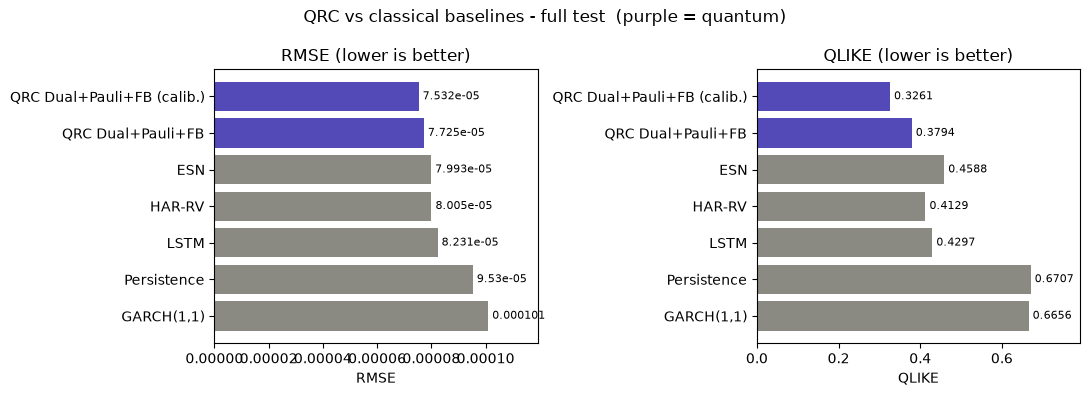

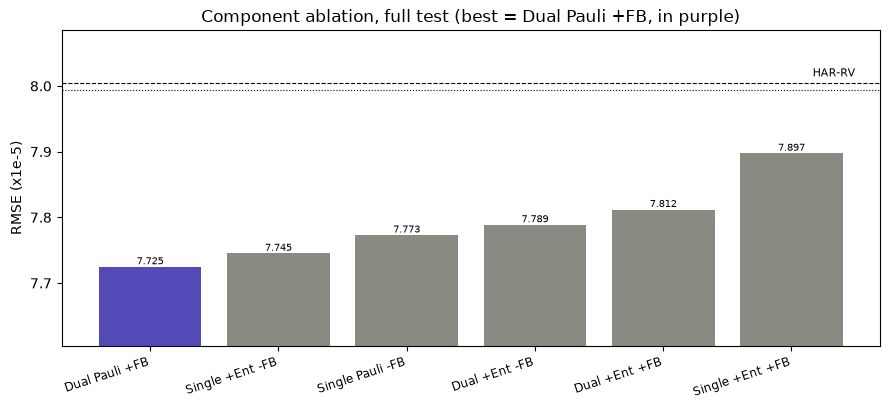

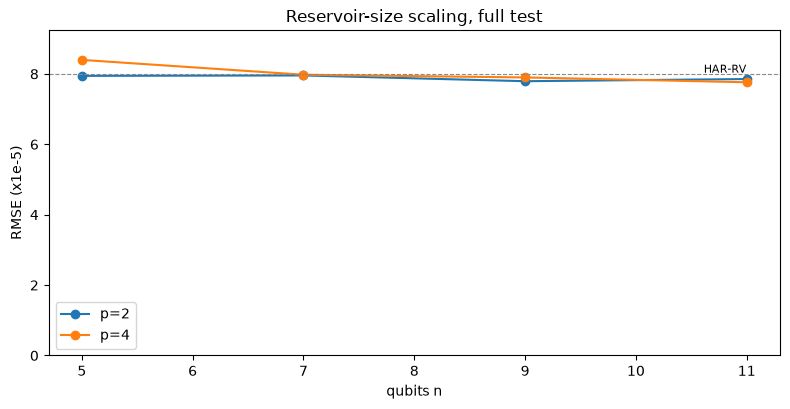

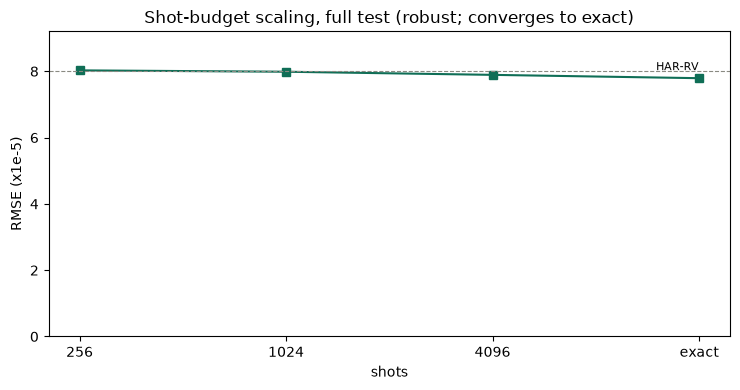

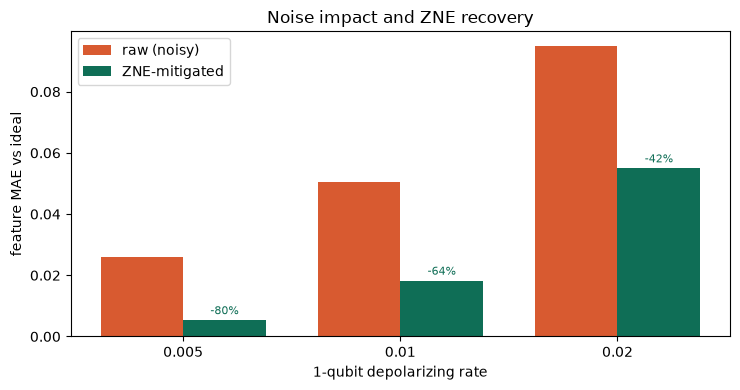

saved figures: ['fig1_baselines.png', 'fig2_ablation.png', 'fig3_scaling.png', 'fig4_shots.png', 'fig5_noise_zne.png']


In [24]:
import matplotlib
if os.environ.get("SKIP_HW_PROMPT"): matplotlib.use("Agg")
import matplotlib.pyplot as plt
os.makedirs("figures",exist_ok=True)
PURPLE,GRAY,TEAL,CORAL="#534AB7","#8A8A82","#0F6E56","#D85A30"
HARr=results["HAR-RV"]["RMSE"]*1e5; ESNr=results["ESN"]["RMSE"]*1e5

# Fig 1 baselines (RMSE + QLIKE), best QRC highlighted, zero-based, value labels
nm=list(results); o=np.argsort([results[k]["RMSE"] for k in nm])[::-1]; nm=[nm[i] for i in o]
rmv=[results[k]["RMSE"] for k in nm]; qlv=[results[k]["QLIKE"] for k in nm]
cc=[PURPLE if results[k]["Src"]=="QRC" else GRAY for k in nm]
fig,ax=plt.subplots(1,2,figsize=(11,4.0))
for a,v,ti,xl in [(ax[0],rmv,"RMSE (lower is better)","RMSE"),(ax[1],qlv,"QLIKE (lower is better)","QLIKE")]:
    bb=a.barh(nm,v,color=cc); a.set_title(ti); a.set_xlabel(xl); a.set_xlim(0,max(v)*1.18)
    for r,x in zip(bb,v): a.text(x,r.get_y()+r.get_height()/2,f" {x:.4g}",va="center",fontsize=8)
fig.suptitle("QRC vs classical baselines - full test  (purple = quantum)"); fig.tight_layout()
fig.savefig("figures/fig1_baselines.png",dpi=150); plt.show()

# Fig 2 ablation (full split), best in purple, HAR/ESN reference lines, value labels
ab=sorted(abl.items(),key=lambda kv:kv[1]["RMSE"]); an=[k for k,_ in ab]; av=[v["RMSE"]*1e5 for _,v in ab]
cols=[PURPLE if i==0 else GRAY for i in range(len(an))]
fig,ax=plt.subplots(figsize=(9,4.2)); b=ax.bar(range(len(an)),av,color=cols)
ax.axhline(HARr,ls="--",c="k",lw=0.8); ax.text(len(an)-.5,HARr+.01,"HAR-RV",fontsize=8,ha="right")
ax.axhline(ESNr,ls=":",c="k",lw=0.8)
ax.set_xticks(range(len(an))); ax.set_xticklabels(an,rotation=18,ha="right",fontsize=8.5)
ax.set_ylabel("RMSE (x1e-5)"); ax.set_ylim(min(av)-0.12,max(HARr,ESNr)+0.08)
ax.set_title(f"Component ablation, full test (best = {an[0]}, in purple)")
for r,v in zip(b,av): ax.text(r.get_x()+r.get_width()/2,v+0.004,f"{v:.3f}",ha="center",fontsize=7.5)
fig.tight_layout(); fig.savefig("figures/fig2_ablation.png",dpi=150); plt.show()

# Fig 3 scaling, zero-based, HAR line
fig,ax=plt.subplots(figsize=(8,4.2))
for p_ in sorted(scal.p.unique()):
    d=scal[scal.p==p_].sort_values("n"); ax.plot(d.n,d.RMSE*1e5,marker="o",label=f"p={p_}")
ax.axhline(HARr,ls="--",c=GRAY,lw=0.8); ax.text(scal.n.max(),HARr+.03,"HAR-RV",fontsize=8,ha="right")
ax.set_ylim(0,max(HARr*1.15,scal.RMSE.max()*1e5*1.1)); ax.set_xlabel("qubits n"); ax.set_ylabel("RMSE (x1e-5)")
ax.set_title("Reservoir-size scaling, full test"); ax.legend(); fig.tight_layout()
fig.savefig("figures/fig3_scaling.png",dpi=150); plt.show()

# Fig 4 shots, zero-based, HAR line
sx=[str(r["shots"]) for r in shots]; sy=[r["RMSE"]*1e5 for r in shots]
fig,ax=plt.subplots(figsize=(7.5,4)); ax.plot(sx,sy,marker="s",color=TEAL)
ax.axhline(HARr,ls="--",c=GRAY,lw=0.8); ax.text(len(sx)-1,HARr+.03,"HAR-RV",fontsize=8,ha="right")
ax.set_ylim(0,max(HARr*1.15,max(sy)*1.1)); ax.set_xlabel("shots"); ax.set_ylabel("RMSE (x1e-5)")
ax.set_title("Shot-budget scaling, full test (robust; converges to exact)"); fig.tight_layout()
fig.savefig("figures/fig4_shots.png",dpi=150); plt.show()

# Fig 5 noise + ZNE with recovery labels
x=np.arange(len(rows)); w=0.38
fig,ax=plt.subplots(figsize=(7.5,4))
ax.bar(x-w/2,[r["raw_mae"] for r in rows],w,label="raw (noisy)",color=CORAL)
ax.bar(x+w/2,[r["zne_mae"] for r in rows],w,label="ZNE-mitigated",color=TEAL)
for i,r in enumerate(rows): ax.text(i+w/2,r["zne_mae"]+0.002,f"-{r['recovered']}%",ha="center",fontsize=8,color=TEAL)
ax.set_xticks(x); ax.set_xticklabels([r["depol_1q"] for r in rows]); ax.set_xlabel("1-qubit depolarizing rate")
ax.set_ylabel("feature MAE vs ideal"); ax.set_title("Noise impact and ZNE recovery"); ax.legend()
fig.tight_layout(); fig.savefig("figures/fig5_noise_zne.png",dpi=150); plt.show()
print("saved figures:",sorted(os.listdir("figures")))

### 19. Reproducibility summary
- **Headline model:** Dual + Pauli + Feedback (hardware-native). **Calibrated** variant adds a train-fit bias correction (improves QLIKE).
- **Seed** SEED=7; state-vector lane deterministic. **Data** from committed `data/market_data.csv` (build via `fetch_data.ipynb`).
- **Studies** run on the full split by default; raise/lower `study_sample`, grids as needed.
- **Regime accuracy** ~62% reported honestly (a dedicated classifier did not beat it on this proxy).
- **Hardware:** `ibm_backend='auto'` selects the least-busy eligible device; feature-level agreement is the reported metric.
- **For the write-up:** copy the Section 11 table, the calibrated QLIKE, and the study/figure outputs directly.
